# **Modelling and Evaluation for Predicting Step Count**

## Objectives

* Attempt to create a model that can predict an individuals step count based on other smartwatch health data

## Inputs

* unclean_smartwatch_health_data.csv

## Outputs

* Step Count prediction model

---

# Change working directory

We need to change the working directory from its current folder to its parent folder.

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project/jupyter_notebooks'

We want to make the parent of the current directory the new current directory.

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project'

## Load Data

Load data and drop User ID

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv('inputs/smartwatch_health_data_untouched/unclean_smartwatch_health_data.csv').drop("User ID", axis=1)
df.head()

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


Setup path to output folder.

In [5]:
# Change version variable to store outputs in different folder
version = "v1"

OutputFolder = f"outputs/{version}/predict_step_count/"
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

## Data Cleaning and Engineering

Setup custom transformations.

In [6]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Replace 'Very High' with 10 in 'Stress Level' and convert columns to numeric
class DataTypeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Replace 'Very High' with 10 in 'Stress Level'
        X['Stress Level'] = X['Stress Level'].replace('Very High', 10)

        # Convert columns to numeric, handling non-numeric values
        X['Sleep Duration (hours)'] = pd.to_numeric(X['Sleep Duration (hours)'], errors='coerce')
        X['Stress Level'] = pd.to_numeric(X['Stress Level'], errors='coerce')

        return X


# Reduced for the discretized version of the Stress level variable, as dont need to replace 'Very High' with 10
class DataTypeTransformer2(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert columns to numeric, handling non-numeric values
        X['Sleep Duration (hours)'] = pd.to_numeric(X['Sleep Duration (hours)'], errors='coerce')
        return X

# Impute missing values (not for Activity Level)
from sklearn.impute import KNNImputer

class KNNImputerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors
        self.imputer = KNNImputer(n_neighbors=self.n_neighbors)

    def fit(self, X, y=None):
        # Identify numerical columns
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.imputer.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        # Impute numerical columns
        X[self.num_cols] = self.imputer.transform(X[self.num_cols])
        return X


# Handle Outliers
from feature_engine.outliers import Winsorizer

class WinsorizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.winsorizers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Winsorizers for each variable
        self.winsorizers['Sleep Duration (hours)'] = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.winsorizers['Heart Rate (BPM)'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.winsorizers['Blood Oxygen Level (%)'] = Winsorizer(
            capping_method='iqr', tail='left', fold=1.5, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.winsorizers['Step Count'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Winsorizers
        for winsorizer in self.winsorizers.values():
            X = winsorizer.transform(X)
        return X


class FloatToInt(BaseEstimator, TransformerMixin):
    def __init__(self, columns=['Stress Level']):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert specified columns to integer
        for col in self.columns:
            X[col] = X[col].astype(int)
        return X

# Predict missing values in 'Activity Level'
from sklearn.ensemble import RandomForestClassifier

class CategoricalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_column='Activity Level', random_state=42):
        self.target_column = target_column
        self.random_state = random_state
        self.classifier = RandomForestClassifier(random_state=self.random_state)
        self.original_categories = None

    def fit(self, X, y=None):
        X = X.copy()
        # Save original categories
        X[self.target_column] = X[self.target_column].astype('category')
        self.original_categories = X[self.target_column].cat.categories

        # Encode target column
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Split data
        self.train_data = X.dropna(subset=[self.target_column])
        self.test_data = X[X[self.target_column].isna()]

        # Features and target
        self.X_train = self.train_data.drop(columns=[self.target_column])
        self.y_train = self.train_data[self.target_column].astype(int)

        # Fit classifier
        self.classifier.fit(self.X_train, self.y_train)
        return self

    def transform(self, X):
        X = X.copy()
        # Encode target column
        X[self.target_column] = X[self.target_column].astype('category')
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Identify missing values
        missing_mask = X[self.target_column].isna()
        if missing_mask.any():
            X_missing = X[missing_mask]
            X_missing_features = X_missing.drop(columns=[self.target_column])
            # Predict missing values
            X.loc[missing_mask, self.target_column] = self.classifier.predict(X_missing_features)

        # Convert to int and decode categories
        X[self.target_column] = X[self.target_column].astype(int)
        X[self.target_column] = pd.Categorical.from_codes(
            X[self.target_column], categories=self.original_categories
        )
        return X


# Correct mis-spelled values in Activity Level
class CategoryCorrector(BaseEstimator, TransformerMixin):
    def __init__(self, column='Activity Level'):
        self.column = column
        self.class_mapping = {
            'Seddentary': 'Sedentary',
            'Highly_Active': 'Highly Active',
            'Actve': 'Active'
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = X[self.column].replace(self.class_mapping)
        return X


# Smooth data using K-Nearest Neighbors
from sklearn.neighbors import NearestNeighbors

class DataSmoother(BaseEstimator, TransformerMixin):
    def __init__(self, k=3):
        self.k = k
        self.nn = NearestNeighbors(n_neighbors=self.k)

    def fit(self, X, y=None):
        X = X.copy()
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.nn.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        distances, indices = self.nn.kneighbors(X[self.num_cols])

        # Smooth numerical columns
        for i, col in enumerate(self.num_cols):
            X[col] = [np.mean(X.iloc[indices[row_idx]][col]) for row_idx in range(len(X))]
        return X


# Trim outliers again after smoothing
from feature_engine.outliers import OutlierTrimmer

class OutlierTrimmerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.trimmers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Outlier Trimmers for each variable
        self.trimmers['Heart Rate (BPM)'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.trimmers['Blood Oxygen Level (%)'] = OutlierTrimmer(
            capping_method='quantiles', tail='left', fold=0.05, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.trimmers['Sleep Duration (hours)'] = OutlierTrimmer(
            capping_method='quantiles', tail='both', fold=0.05, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.trimmers['Step Count'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Outlier Trimmers sequentially
        for trimmer in self.trimmers.values():
            X = trimmer.transform(X)
        return X


from sklearn.preprocessing import MinMaxScaler, StandardScaler
class DataFrameScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_columns=None):
        self.exclude_columns = exclude_columns
        self.scaler = MinMaxScaler()
    
    def fit(self, X, y=None):
        X_to_scale = X.drop(columns=self.exclude_columns)
        self.scaler.fit(X_to_scale)
        return self
    
    def transform(self, X):
        X_to_scale = X.drop(columns=self.exclude_columns)
        X_excluded = X[self.exclude_columns]
        X_scaled = pd.DataFrame(self.scaler.transform(X_to_scale), columns=X_to_scale.columns)
        X_final = pd.concat([X_scaled, X_excluded.reset_index(drop=True)], axis=1)
        return X_final

## ML pipeline

---

I aim to perform feature selection for the Step Count variable to determine if there is a viable or evident way to predict it. Alternatively, it may prove more appropriate to approach this as a traditional data analysis problem, which I have already explored. Based on initial findings, most variables showed slight correlations. However, for this specific dataset, even a modest correlation could be considered significant, as the acceptable level of correlation varies across datasets. The highest correlation observed was 0.07 (between Step Count and Stress Level), which, while seemingly low, might hold substantial relevance within this context.

Setup cleaning pipeline

In [7]:
from sklearn.pipeline import Pipeline
# encoding
from feature_engine.encoding import OrdinalEncoder 

def CleanEnginPipeline():
    cleaning_engineering_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        # I have chosen OrdinalEncoder as our categorical variables have an ordinal relationship
        ('minmax', DataFrameScaler(exclude_columns=[])),
    ])
    return cleaning_engineering_pipeline

Fit the clean

In [8]:
df_clean = CleanEnginPipeline().fit_transform(df)
df_clean.head()

/tmp/ipykernel_1123/1938814800.py:173: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[self.column] = X[self.column].replace(self.class_mapping)


,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,0.382184,0.450366,0.264732,0.599978,0.0,0.222222
1,0.519542,0.544723,0.035051,0.251828,0.0,0.555556
2,0.080689,0.523668,0.670296,0.737055,0.5,0.185185
3,0.296439,0.486656,0.761901,0.260212,0.0,0.370370
4,0.757703,0.264152,0.496127,0.930827,0.0,0.777778


# Finding the best algorithm for the task

Setup a GridSearchCV function to find the best algorithm for this task.

In [9]:
from sklearn.pipeline import Pipeline

### Data Cleaning and Feature Engineering
from feature_engine.imputation import MeanMedianImputer
from feature_engine.imputation import CategoricalImputer
from feature_engine.encoding import OrdinalEncoder
from feature_engine.selection import SmartCorrelatedSelection

### Feat Scaling
from sklearn.preprocessing import StandardScaler

### Feat Selection
from sklearn.feature_selection import SelectFromModel

### ML algorithms 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression



def PipelineOptimization(model):
  pipeline_base = Pipeline([
      ("feat_selection",  SelectFromModel(model) ),

      ("model", model ),
    ])

  return pipeline_base


from sklearn.model_selection import GridSearchCV
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")
            model=  PipelineOptimization(self.models[key])

            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs, verbose=verbose, scoring=scoring)
            gs.fit(X,y)
            self.grid_searches[key] = gs    

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                 'estimator': key,
                 'min_score': min(scores),
                 'max_score': max(scores),
                 'mean_score': np.mean(scores),
                 'std_score': np.std(scores),
            }
            return pd.Series({**params,**d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]        
                scores.append(r.reshape(len(params),1))

            all_scores = np.hstack(scores)
            for p, s in zip(params,all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns], self.grid_searches


models_search = {
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "LinearRegression": LinearRegression(),
    "xgb": XGBRegressor(random_state=42),
}

params_search = {
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "GradientBoostingRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "LinearRegression": {},
    "xgb": {},
}

Split data.

In [10]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(
    df_clean.drop("Step Count", axis=1),
    df_clean["Step Count"],
    test_size=0.2,
    random_state=42
)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(6237, 5) (6237,) (1560, 5) (1560,)


Perform GridSearchCV with negative mean squared error as the scoring method.

In [12]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring = "neg_mean_squared_error",
           cv=3,
           n_jobs=-1,
           verbose=1)


Running GridSearchCV for DecisionTreeRegressor 

Fitting 3 folds for each of 1 candidates, totalling 3 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 3 folds for each of 1 candidates, totalling 3 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 3 folds for each of 1 candidates, totalling 3 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 3 folds for each of 1 candidates, totalling 3 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 3 folds for each of 1 candidates, totalling 3 fits

Running GridSearchCV for LinearRegression 

Fitting 3 folds for each of 1 candidates, totalling 3 fits

Running GridSearchCV for xgb 

Fitting 3 folds for each of 1 candidates, totalling 3 fits


Collect and show the best algorithm and parameters.

In [13]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
best_model = grid_search_summary.iloc[0,0]
best_parameters = grid_search_pipelines[best_model].best_params_
grid_search_summary 

,estimator,min_score,mean_score,max_score,std_score
3,ExtraTreesRegressor,-0.048118,-0.046147,-0.044996,0.0014
1,RandomForestRegressor,-0.050194,-0.047788,-0.046455,0.001704
6,xgb,-0.058336,-0.054529,-0.051673,0.002802
2,GradientBoostingRegressor,-0.05825,-0.056124,-0.054588,0.001552
5,LinearRegression,-0.060137,-0.057557,-0.055776,0.001868
4,AdaBoostRegressor,-0.061474,-0.059667,-0.057422,0.001683
0,DecisionTreeRegressor,-0.084661,-0.081685,-0.079826,0.002126


ExtraTrees Regressor seems the best with this task as a regression problem.

Lets check the feature importance calculated by the ExtraTrees regressor.

* These are the 3 most important features in descending order. The model was trained on them: 
['Heart Rate (BPM)', 'Blood Oxygen Level (%)', 'Sleep Duration (hours)']


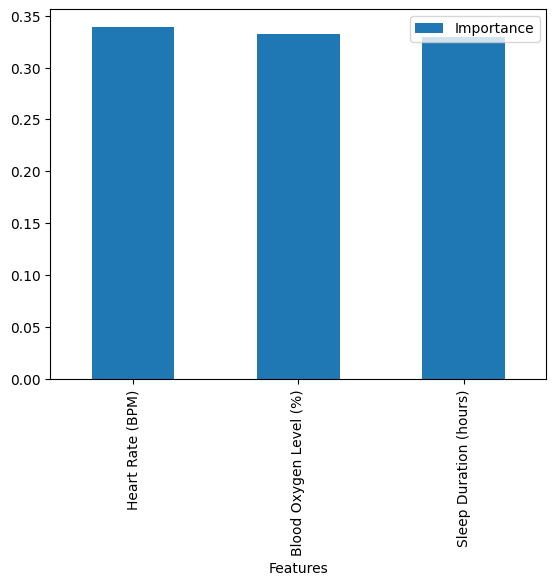

In [15]:
import matplotlib.pyplot as plt

pipeline = Pipeline([
    ("feat_selection", SelectFromModel(models_search[best_model])),
    ("model", models_search[best_model]),
])
pipeline.fit(X_train, y_train)

def feature_importance_tree_based_models(model, columns):

    df_feature_importance = (pd.DataFrame(data={
        'Features': columns,
        'Importance': model.feature_importances_})
    .sort_values(by='Importance', ascending=False)
    )

    best_features = df_feature_importance['Features'].to_list()

    print(f"* These are the {len(best_features)} most important features in descending order. "
          f"The model was trained on them: \n{df_feature_importance['Features'].to_list()}")

    df_feature_importance.plot(kind='bar', x='Features', y='Importance')
    plt.show()

feature_importance_tree_based_models(model=pipeline['model'],
                                     columns=X_train.columns[pipeline['feat_selection'].get_support()])

It seems Heart Rate, Blood Oxygen Level and Sleep Duration are the top features for this task as a regression based problem.

Lets now do a more in depth assessment.

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

counter = 0


def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)


def regression_evaluation(X, y, pipeline):
    prediction = pipeline.predict(X)
    print('R2 Score:', r2_score(y, prediction).round(3))
    print('Mean Absolute Error:', mean_absolute_error(y, prediction).round(3))
    print('Mean Squared Error:', mean_squared_error(y, prediction).round(3))
    print('Root Mean Squared Error:', np.sqrt(
        mean_squared_error(y, prediction)).round(3))
    print("\n")


def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    global counter
    counter += 1
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train, y=y_train, color='red', ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")

    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test, y=y_test, color='red', ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Test Set")

    filename = os.path.join(OutputFolder, f'regression_evaluation_plots_{counter}.png')
    plt.savefig(filename)
    plt.show()


Check the performance.

Model Evaluation 

* Train Set
R2 Score: 1.0
Mean Absolute Error: 0.0
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0


* Test Set
R2 Score: 0.335
Mean Absolute Error: 0.126
Mean Squared Error: 0.04
Root Mean Squared Error: 0.2




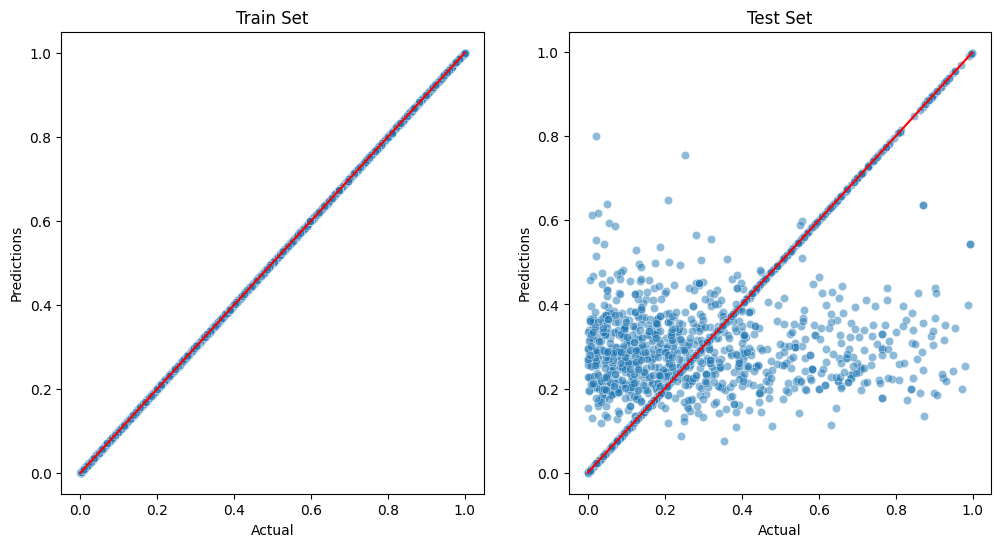

In [17]:
regression_performance(X_train, y_train, X_test, y_test, pipeline)
regression_evaluation_plots(X_train, y_train,
                            X_test, y_test,
                            pipeline, alpha_scatter=0.5)

This looks like major overfitting, lets try some hyperparameters.

In [18]:
models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
}

params_search = {
    "ExtraTreesRegressor": {
        "model__n_estimators": [60, 100, 160],
        "model__max_depth": [5, 10, 20],
        "model__min_samples_split": [5, 10, 20],
        "model__max_leaf_nodes": [15, 20, 25],
    },
}

And try optimization search again with the hyperparameters added above.

In [19]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring = "neg_mean_squared_error",
           cv=3,
           n_jobs=-1,
           verbose=1)

grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
best_model = grid_search_summary.iloc[0,0]
best_parameters = grid_search_pipelines[best_model].best_params_
grid_search_summary


Running GridSearchCV for ExtraTreesRegressor 

Fitting 3 folds for each of 81 candidates, totalling 243 fits


KeyboardInterrupt: 

In [ ]:

regression_performance(X_train, y_train, X_test, y_test, grid_search_pipelines)
regression_evaluation_plots(X_train, y_train,
                            X_test, y_test,
                            pipeline, alpha_scatter=0.5)

It looks like the hyperparameters helped.

Overall it seems this task as a regression problem would need alot of tweaking and hyperparameter tuning. I would like to do this but I have a limited time to finish this project.

## Regression and PCA

Next I will try and see if a PCA regression based model will perform better for this task.

Setup cleaning/engineering pipeline with PCA. From the engineering notebook we know that between 2-4 components is optimal, removing Heart Rate and Sleep Duration was effective in the clustering task.

In [10]:
from sklearn.decomposition import PCA

def PCAPipeline():
    pca_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        ('minmax', DataFrameScaler(exclude_columns=["Activity Level", "Stress Level"])),
        # Activity Level and Stress Level, I feel dont need to be scaled, as they are already quite ordinal
        ('pca', PCA(n_components=3, random_state=42))
    ])
    return pca_pipeline

Fit the pipeline

In [11]:
pipeline_pca = PCAPipeline()
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, '\n', type(df_pca))

/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:97: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return is_numeric(pd.to_numeric(column, errors="ignore"))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))

(7797, 3) 
 <class 'numpy.ndarray'>


Assess components

In [12]:
n_components = 3

pca = PCA(n_components=n_components).fit(df_pca)
x_PCA = pca.transform(df_pca) # array with transformed PCA

ComponentsList = ["Component " + str(number) for number in range(n_components)]
dfExplVarRatio = pd.DataFrame(
    data= np.round(100 * pca.explained_variance_ratio_ ,2),
    index=ComponentsList,
    columns=['Explained Variance Ratio (%)'])

PercentageOfDataExplained = dfExplVarRatio['Explained Variance Ratio (%)'].sum()

print(f"* The {n_components} components explain {round(PercentageOfDataExplained,2)}% of the data \n")
print(dfExplVarRatio)

sns.scatterplot(x=x_PCA[:,0], y=x_PCA[:,1])
plt.xlabel('Component 0')
plt.ylabel('Component 1')
plt.savefig(os.path.join(OutputFolder, 'PCA_components.png'))
plt.show()

* The 3 components explain 100.0% of the data 

             Explained Variance Ratio (%)
Component 0                         82.54
Component 1                         16.16
Component 2                          1.30


NameError: name 'sns' is not defined

Three components explains 100% of this data, I will carry on with this value.

Setup potential algorithms to test with GridSearchCV.

In [13]:
models_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42),
}

params_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    "XGBRegressor": {},
}

Fit again with the best n_components. This step looks a little awkward, but its because of the custom transformers throwing errors if Step Count isnt present during the initial pipeline fit, this is why I have had to seperate the PCA step out.

In [14]:
pipeline = PCAPipeline()
pipeline_pca = Pipeline(pipeline.steps[:10])
df_pca = pipeline_pca.fit_transform(df)
df_pca.drop('Step Count', axis=1, inplace=True)

df_pca = PCA(n_components=4).fit_transform(df_pca)

/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:97: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return is_numeric(pd.to_numeric(column, errors="ignore"))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))

Split the data

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_pca,
                                                    df_clean['Step Count'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

* Train set: (6237, 4) (6237,) 
* Test set: (1560, 4) (1560,)


Perform GridSearchCV

In [16]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring = "neg_mean_squared_error",
           cv=5,
           n_jobs=-1,
           verbose=1)

grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
best_model = grid_search_summary.iloc[0,0]
best_parameters = grid_search_pipelines[best_model].best_params_
grid_search_summary


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,min_score,mean_score,max_score,std_score
3,ExtraTreesRegressor,-0.051964,-0.049124,-0.046356,0.002095
2,RandomForestRegressor,-0.05374,-0.050188,-0.047828,0.002189
5,GradientBoostingRegressor,-0.060163,-0.05616,-0.05166,0.002757
6,XGBRegressor,-0.061117,-0.057221,-0.052357,0.002952
0,LinearRegression,-0.06085,-0.057705,-0.053603,0.002458
4,AdaBoostRegressor,-0.066037,-0.062559,-0.058734,0.002366
1,DecisionTreeRegressor,-0.08869,-0.085691,-0.081002,0.002738


Assess performance

In [17]:
best_pipeline = grid_search_pipelines[best_model].best_estimator_

regression_performance(X_train, y_train, X_test, y_test, best_pipeline)
regression_evaluation_plots(X_train, y_train,
                            X_test, y_test,
                            best_pipeline, alpha_scatter=0.5)

NameError: name 'regression_performance' is not defined

Again, it looks like the PCA regression model has overfitted. I would have liked to tweak this and test different hyperparameters. But I do not have enough time in this project.

## Convert to classification

Finally, I will try converting this problem into a classification problem to see if there is any improved results.

Construct the pipeline

In [18]:
def CleanEnginPipelineDisc():
    cleaning_engineering_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        ('minmax', DataFrameScaler(exclude_columns=["Activity Level", "Step Count"])),
    ])
    return cleaning_engineering_pipeline

Perform an Equal Width Discretiser on the target "Step Count", including 7 bins.

In [ ]:
from feature_engine.discretisation import EqualWidthDiscretiser
import seaborn as sns
import matplotlib.pyplot as plt

disc = EqualWidthDiscretiser(bins=7, variables=['Step Count'])
df_clf = disc.fit_transform(df_clean)


print(f"* The classes represent the following ranges: \n{disc.binner_dict_} \n")

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clf, x='Step Count')


plt.xticks(ticks=range(7), labels=['<3524', '3525-7048', '7049-10572', '10573-14096', '14097-17620', '17621-20000', '20000+'])
plt.show()


Setup potential classifier algorithms

In [19]:
models_search = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(),
}

params_search = {
    "DecisionTreeClassifier": {},
    "RandomForestClassifier": {},
    "GradientBoostingClassifier": {},
    "ExtraTreesClassifier": {},
    "AdaBoostClassifier": {},
    "LogisticRegression": {},
}

Replace the dataframes Step Count variables to the classification version just created above. Then split the data.

In [ ]:
pipeline = CleanEnginPipelineDisc()
df1 = pipeline.fit_transform(df)
df1["Step Count"] = df_clf["Step Count"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df1.drop(columns=['Step Count']),
                                                    df1['Step Count'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

Perform GridSearchCV for classification.

In [ ]:
# Convert numeric bins to string labels
y_train = y_train.astype(str)
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train.values.ravel(),
                 cv=5,
                 n_jobs=-1,
                 verbose=1,
                 scoring='accuracy')

Collect and view best results.

In [ ]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
best_model = grid_search_summary.iloc[0,0]
pipeline_clf = grid_search_pipelines[best_model].best_estimator_
grid_search_summary

This has the best performance of the models tested, this was also the same for predicting Stress Level.

Perform a performance test.

In [18]:
import os
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import sys

# Set output folder directly
output_folder = OutputFolder  # Ensure this is a valid directory

def confusion_matrix_and_report(X, y, pipeline, label_map, file):
    prediction = pipeline.predict(X)

    # Write the confusion matrix to the file
    file.write('---  Confusion Matrix  ---\n')
    file.write(pd.DataFrame(confusion_matrix(y_true=prediction, y_pred=y),
                            columns=["Actual " + sub for sub in label_map],
                            index=["Prediction " + sub for sub in label_map]
                            ).to_string())
    file.write("\n\n")

    # Write the classification report to the file
    file.write('---  Classification Report  ---\n')
    file.write(classification_report(y, prediction, target_names=label_map))
    file.write("\n\n")


def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    # Ensure the output folder exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Specify the output file path
    output_path = os.path.join(output_folder, 'classification_report.txt')

    # Open the output file in write mode
    with open(output_path, 'w') as file:
        file.write("#### Train Set #### \n\n")
        confusion_matrix_and_report(X_train, y_train, pipeline, label_map, file)

        file.write("#### Test Set ####\n\n")
        confusion_matrix_and_report(X_test, y_test, pipeline, label_map, file)

    # Print the results to the console
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map, sys.stdout)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map, sys.stdout)

    print(f"Results saved to: {output_path}")

Setup classifier

In [ ]:
def DiscretPipeline():
    pipeline = Pipeline([
        ('feature_selection', SelectFromModel(estimator=RandomForestClassifier())),
        ('model',  RandomForestClassifier())
    ])
    return pipeline

Fit and test performance

In [ ]:
pipeline = DiscretPipeline()

y_train = y_train.astype(str)
y_test = y_test.astype(str)

pipeline.fit(X_train, y_train.values.ravel())

label_map = [str(label) for label in y_train.value_counts().index.to_list()]


clf_performance(X_train=X_train, y_train=y_train.values.ravel(),
                X_test=X_test, y_test=y_test.values.ravel(),
                pipeline=pipeline,
                label_map=label_map)

Evaluate feature importance

In [ ]:
import matplotlib.pyplot as plt

pipeline = Pipeline([
    ("feat_selection", SelectFromModel(models_search[best_model])),
    ("model", models_search[best_model]),
])
pipeline.fit(X_train, y_train)

def feature_importance_tree_based_models(model, columns):

    df_feature_importance = (pd.DataFrame(data={
        'Features': columns,
        'Importance': model.feature_importances_})
    .sort_values(by='Importance', ascending=False)
    )

    best_features = df_feature_importance['Features'].to_list()

    print(f"* These are the {len(best_features)} most important features in descending order. "
          f"The model was trained on them: \n{df_feature_importance['Features'].to_list()}")

    df_feature_importance.plot(kind='bar', x='Features', y='Importance')
    plt.show()

feature_importance_tree_based_models(model=pipeline['model'],
                                     columns=X_train.columns[pipeline['feat_selection'].get_support()])

Great, the classification model performed the best out of the regression and PCA regression versions of the model. I will build this model fully.

---

The classification model performed the best. I will build it fully and save it.

In [ ]:
# Save the discretized data
df_discret.to_csv(OutputFolder + 'discretized_smartwatch_health_data.csv', index=False)

Setup final pipeline.

In [10]:
def FullDiscretPipelineFinal():
    best_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        ('minmax', DataFrameScaler(exclude_columns=[])),
    ])
    return best_pipeline

Perform EqualWidth Discretiser

* The classes represent the following ranges: 
{'Step Count': [-inf, 0.14285714285714285, 0.2857142857142857, 0.42857142857142855, 0.5714285714285714, 0.7142857142857142, 0.8571428571428571, inf]} 



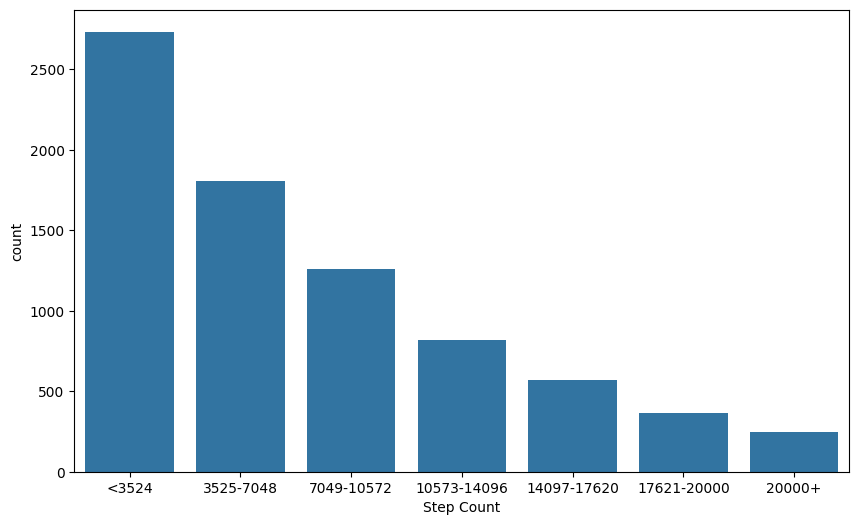

In [11]:
from feature_engine.discretisation import EqualWidthDiscretiser
import seaborn as sns
import matplotlib.pyplot as plt

disc = EqualWidthDiscretiser(bins=7, variables=['Step Count'])
df_clf = disc.fit_transform(df_clean)


print(f"* The classes represent the following ranges: \n{disc.binner_dict_} \n")

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clf, x='Step Count')


plt.xticks(ticks=range(7), labels=['<3524', '3525-7048', '7049-10572', '10573-14096', '14097-17620', '17621-20000', '20000+'])
plt.show()


Setup classifier

In [12]:
def DiscretPipelineModel():
    pipeline = Pipeline([
        ('feature_selection', SelectFromModel(estimator=ExtraTreesClassifier())),
        ('model',  ExtraTreesClassifier())
    ])
    return pipeline

Associate the classification version of Step Count with the transformed dataset, and split the data.

In [15]:
best_pipeline = FullDiscretPipelineFinal()
df_discret = best_pipeline.fit_transform(df.copy())
df_discret["Step Count"] = df_clf["Step Count"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_discret.drop(columns=['Step Count']),
                                                    df_discret['Step Count'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:97: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return is_numeric(pd.to_numeric(column, errors="ignore"))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))

* Train set: (6237, 5) (6237,) 
* Test set: (1560, 5) (1560,)


Fit the model to the train set.

In [16]:
best_pipeline_modeler = DiscretPipelineModel()
best_pipeline_modeler.fit(X_train, y_train)

Pipeline(steps=[('feature_selection',
                 SelectFromModel(estimator=ExtraTreesClassifier())),
                ('model', ExtraTreesClassifier())])

Calculate performance

In [21]:
label_map = ['<3524', '3525-7048', '7049-10572', '10573-14096', '14097-17620', '17621-20000', '20000+']

clf_performance(X_train=X_train, y_train=y_train.values.ravel(),
                X_test=X_test, y_test=y_test.values.ravel(),
                pipeline=best_pipeline_modeler,
                label_map=label_map)

#### Train Set #### 

---  Confusion Matrix  ---
                        Actual <3524  Actual 3525-7048  Actual 7049-10572  Actual 10573-14096  Actual 14097-17620  Actual 17621-20000  Actual 20000+
Prediction <3524                2206                 0                  0                   0                   0                   0              0
Prediction 3525-7048               0              1429                  0                   0                   0                   0              0
Prediction 7049-10572              0                 0               1001                   0                   0                   0              0
Prediction 10573-14096             0                 0                  0                 671                   0                   0              0
Prediction 14097-17620             0                 0                  0                   0                 452                   0              0
Prediction 17621-20000             0                 0   

---

Predicting stress level as a categoric variable was successfull, this will be noted in the dashboard page for this task.

---